In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Exploratory Data Analysis

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

daily_df = pd.read_csv(
    "../data/processed/bike_weather_daily.csv"
)
print(daily_df.head(10))
daily_df["date"] = pd.to_datetime(
    daily_df["date"]
)

         date  fremont_bridge  temperature_2m  precipitation  wind_speed_10m
0  2012-10-02          1938.0       13.300000            0.0        5.654545
1  2012-10-03          3521.0       11.495833            0.0       12.845833
2  2012-10-04          3475.0       11.750000            0.0       11.070833
3  2012-10-05          3148.0       12.079167            0.0        9.095833
4  2012-10-06          2006.0       12.454167            0.0        8.541667
5  2012-10-07          2142.0       13.266667            0.0        7.879167
6  2012-10-08          3537.0       13.754167            0.0        5.379167
7  2012-10-09          3501.0       13.316667            0.0        6.041667
8  2012-10-10          3235.0       12.983333            0.0        3.541667
9  2012-10-11          3047.0       11.250000            0.0        4.212500


## Feature Engineering

Calendar, lag, and rolling-window features are created
to capture seasonality, autocorrelation, and local trends
in bicycle traffic.

In [27]:
#Study seasonal trends in data

from src.features.build_features import (
    add_calendar_features,
    add_lag_features,
    add_rolling_features
)

#add features for analysis
features_df = add_calendar_features(
    daily_df
)

features_df = add_lag_features(
    features_df
)

features_df = add_rolling_features(
    features_df
)

features_df.head(10)

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,month_name,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30
0,2012-10-02,1938.0,13.300000,0.0,5.654545,1,10,2012,276,October,0,NaN,NaN,NaN,NaN
1,2012-10-03,3521.0,11.495833,0.0,12.845833,2,10,2012,277,October,0,1938.0,NaN,NaN,NaN
2,2012-10-04,3475.0,11.750000,0.0,11.070833,3,10,2012,278,October,0,3521.0,NaN,NaN,NaN
3,2012-10-05,3148.0,12.079167,0.0,9.095833,4,10,2012,279,October,0,3475.0,NaN,NaN,NaN
4,2012-10-06,2006.0,12.454167,0.0,8.541667,5,10,2012,280,October,1,3148.0,NaN,NaN,NaN
5,2012-10-07,2142.0,13.266667,0.0,7.879167,6,10,2012,281,October,1,2006.0,NaN,NaN,NaN
6,2012-10-08,3537.0,13.754167,0.0,5.379167,0,10,2012,282,October,0,2142.0,NaN,2823.857143,NaN
7,2012-10-09,3501.0,13.316667,0.0,6.041667,1,10,2012,283,October,0,3537.0,1938.0,3047.142857,NaN
8,2012-10-10,3235.0,12.983333,0.0,3.541667,2,10,2012,284,October,0,3501.0,3521.0,3006.285714,NaN
9,2012-10-11,3047.0,11.250000,0.0,4.212500,3,10,2012,285,October,0,3235.0,3475.0,2945.142857,NaN


In [28]:
#save dataset
features_df.to_csv(
    "../data/processed/bike_weather_features.csv",
    index=False
)

### Dataset Overview

This section summarizes the dimensions,
structure, and descriptive statistics
of the forecasting dataset.

In [29]:
#Get data set overview
print(features_df.shape)
print(features_df.info())
features_df.describe()

(4990, 15)
<class 'pandas.DataFrame'>
RangeIndex: 4990 entries, 0 to 4989
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4990 non-null   datetime64[us]
 1   fremont_bridge   4990 non-null   float64       
 2   temperature_2m   4990 non-null   float64       
 3   precipitation    4990 non-null   float64       
 4   wind_speed_10m   4990 non-null   float64       
 5   day_of_week      4990 non-null   int32         
 6   month            4990 non-null   int32         
 7   year             4990 non-null   int32         
 8   day_of_year      4990 non-null   int32         
 9   month_name       4990 non-null   category      
 10  is_weekend       4990 non-null   int64         
 11  lag_1            4989 non-null   float64       
 12  lag_7            4983 non-null   float64       
 13  rolling_mean_7   4984 non-null   float64       
 14  rolling_mean_30  4961 non-null   float64

,date,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,day_of_week,month,year,day_of_year,is_weekend,lag_1,lag_7,rolling_mean_7,rolling_mean_30
count,4990,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4990.000000,4989.000000,4983.000000,4984.000000,4961.000000
mean,2019-08-01 12:00:00,2577.609619,11.180999,3.408818,10.828060,3.000601,6.498798,2019.084770,182.388778,0.285772,2577.360393,2575.761589,2576.563059,2573.519149
min,2012-10-02 00:00:00,11.000000,-7.554167,0.000000,2.537500,0.000000,1.000000,2012.000000,1.000000,0.000000,11.000000,11.000000,62.714286,629.533333
25%,2016-03-02 06:00:00,1611.250000,6.646875,0.000000,7.279167,1.000000,3.000000,2016.000000,90.000000,0.000000,1611.000000,1610.500000,1846.321429,1837.633333
50%,2019-08-01 12:00:00,2476.500000,10.581250,0.200000,9.535417,3.000000,6.000000,2019.000000,181.000000,0.000000,2476.000000,2475.000000,2505.142857,2500.866667
75%,2022-12-30 18:00:00,3439.750000,16.002083,4.200000,13.141667,5.000000,10.000000,2022.000000,277.000000,1.000000,3439.000000,3436.500000,3355.178571,3330.033333
max,2026-05-31 00:00:00,6428.000000,29.145833,77.000000,37.187500,6.000000,12.000000,2026.000000,366.000000,1.000000,6428.000000,6428.000000,5116.142857,4938.200000
std,NaN,1275.015367,5.793991,6.469149,5.006077,1.999950,3.483072,3.961307,106.502447,0.451826,1275.021604,1273.620523,948.041433,884.785213


### Long-Term Trends

This section investigates how bicycle
ridership changes over years.

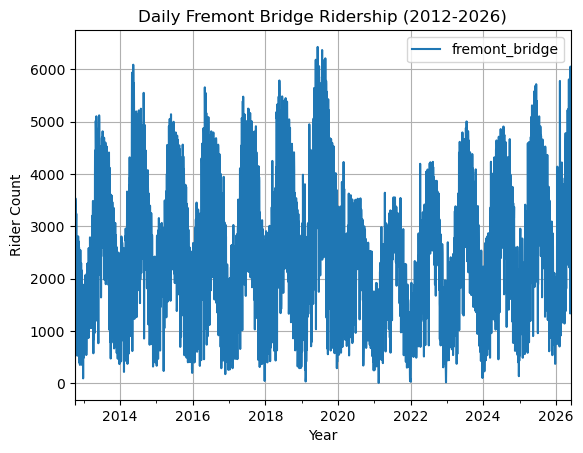

In [30]:
#visualize trends in time
features_df.plot(
    x="date",
    y="fremont_bridge",
    grid=True,
    xlabel="Year",
    ylabel="Rider Count",
    title="Daily Fremont Bridge Ridership (2012-2026)"
)

plt.savefig(
    "../reports/figures/traffic_over_time.png",
    bbox_inches="tight"
)

### Monthly Seasonality

This section investigates how average bicycle ridership
changes throughout the year.

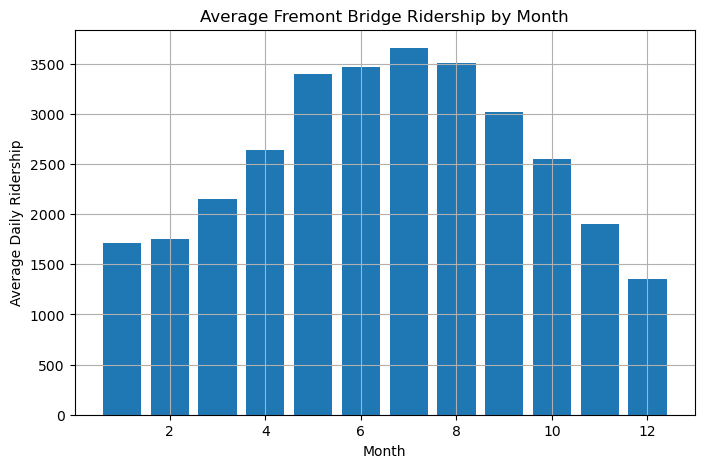

month
1     1712.870968
2     1752.539241
3     2149.604839
4     2639.639286
5     3394.546083
6     3466.879487
7     3658.213400
8     3506.875931
9     3024.358974
10    2555.997691
11    1902.295238
12    1352.529954
Name: fremont_bridge, dtype: float64


<Figure size 640x480 with 0 Axes>

In [31]:
#Plot monthly trends
monthly_avg = (
    features_df
    .groupby("month")
    ["fremont_bridge"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.bar(
    monthly_avg.index,
    monthly_avg.values
)

plt.xlabel("Month")
plt.ylabel("Average Daily Ridership")
plt.title("Average Fremont Bridge Ridership by Month")
plt.grid()
plt.show()

plt.savefig(
    "../reports/figures/monthly_rider_averages.png",
    bbox_inches="tight"
)
print(monthly_avg.sort_index())

### Weekly Seasonality

This section investigates differences between weekday
and weekend bicycle traffic patterns.

   day_of_week  fremont_bridge
0            0     2795.661517
1            1     3152.818373
2            2     3131.504909
3            3     2991.016830
4            4     2626.754558
5            5     1740.060309
6            6     1605.756662


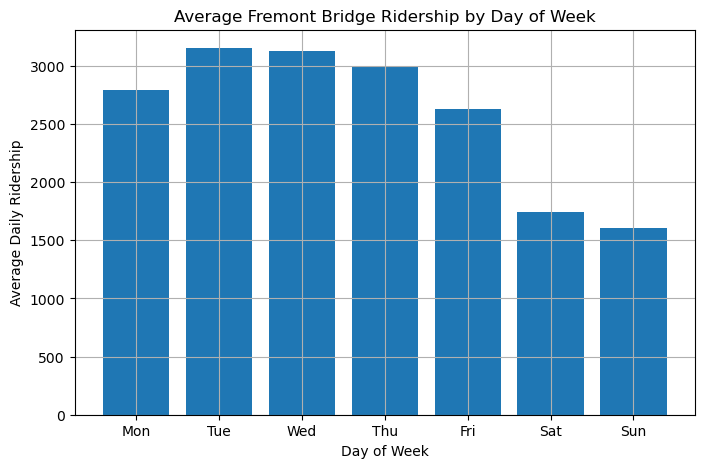

<Figure size 640x480 with 0 Axes>

In [44]:
#Examination of trends over days of the week
weekday_avg = (
    features_df
    .groupby("day_of_week")
    ["fremont_bridge"]
    .mean()
    .reset_index()
)

print(weekday_avg)
weekday_names = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

weekday_avg["day_name"] = (
    weekday_avg["day_of_week"]
    .map(weekday_names)
)

plt.figure(figsize=(8,5))

plt.bar(
    weekday_avg["day_name"],
    weekday_avg["fremont_bridge"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Daily Ridership")
plt.title("Average Fremont Bridge Ridership by Day of Week")
plt.grid()
plt.show()

plt.savefig(
    "../reports/figures/weekday_patterns.png",
    bbox_inches="tight"
)

#### Interpretation

Ridership exhibits a long-term upward trend that was
temporarily disrupted during the COVID-19 pandemic
before recovering in subsequent years.

Strong annual seasonality is present throughout the
dataset. Average daily traffic increases from
approximately 1,350 riders per day in December to more
than 3,650 riders per day in July, making summer
ridership roughly 2.7 times greater than winter
ridership. This seasonal pattern suggests that calendar
features such as month and day-of-year will be important
predictors in forecasting models.

Weekly seasonality is also evident. Average weekday
traffic is substantially higher than weekend traffic,
with ridership peaking on Tuesday and Wednesday and
reaching its lowest levels on Saturday and Sunday. This
pattern suggests that Fremont Bridge traffic is driven
primarily by commuting activity rather than recreational
cycling.

#### Key Findings

- Ridership exhibits strong annual seasonality.
- Ridership declined during the COVID-19 pandemic and later recovered.
- Weekday ridership is substantially higher than weekend ridership.
- Temperature is positively correlated with ridership.
- Precipitation negatively impacts ridership.
- Lag features appear highly predictive.
- Fremont Bridge traffic appears to be primarily commuter-driven.

### Weather Effects on Ridership

This section investigates how temperature,
precipitation, and wind speed relate to daily
bike traffic.

                temperature_2m  fremont_bridge
temperature_2m        1.000000        0.579876
fremont_bridge        0.579876        1.000000


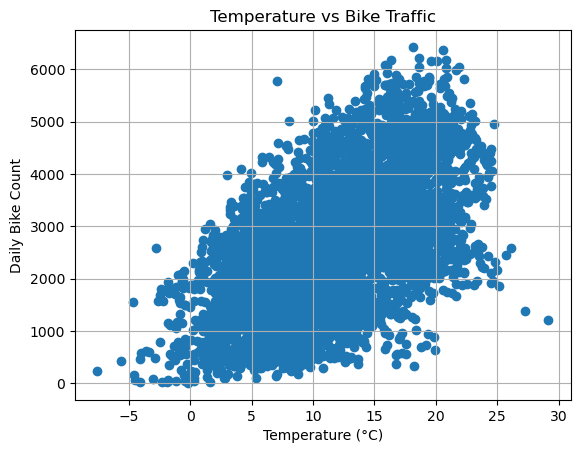

<Figure size 640x480 with 0 Axes>

In [33]:
#Weather trends

#investigate correlation
print(features_df[["temperature_2m", "fremont_bridge"]].corr())

plt.scatter(
    features_df["temperature_2m"],
    features_df["fremont_bridge"]
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Daily Bike Count")
plt.title("Temperature vs Bike Traffic")
plt.grid()
plt.show()

plt.savefig(
    "../reports/figures/temperature_vs_bike_traffic.png",
    bbox_inches="tight"
)

#### Interpretation

Temperature exhibits a moderate positive correlation
with bicycle traffic (r = 0.58). Warmer days tend to
have higher ridership, suggesting temperature is an
important predictor for forecasting models.

In [34]:
#investigate correlation
features_df[["precipitation", "fremont_bridge"]].corr()

,precipitation,fremont_bridge
precipitation,1.000000,-0.377144
fremont_bridge,-0.377144,1.000000


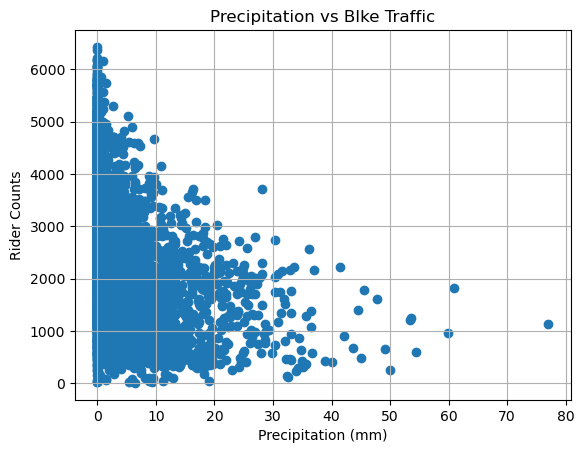

<Figure size 640x480 with 0 Axes>

In [35]:
plt.scatter(
    features_df["precipitation"],
    features_df["fremont_bridge"],
)

plt.grid()
plt.xlabel("Precipitation (mm)")
plt.ylabel("Rider Counts")
plt.title("Precipitation vs BIke Traffic")
plt.show()

plt.savefig(
    "../reports/figures/precipitation_vs_bike_traffic.png",
    bbox_inches="tight"
)

In [36]:
#Rainy vs dry day averages
features_df["rainy_day"] = (
    features_df["precipitation"] > 0
)

features_df.groupby(
    "rainy_day"
)["fremont_bridge"].mean()

rainy_day
False    3188.202494
True     2094.177917
Name: fremont_bridge, dtype: float64

In [37]:
#investigate correlation
features_df[["wind_speed_10m", "fremont_bridge"]].corr()

,wind_speed_10m,fremont_bridge
wind_speed_10m,1.000000,-0.307724
fremont_bridge,-0.307724,1.000000


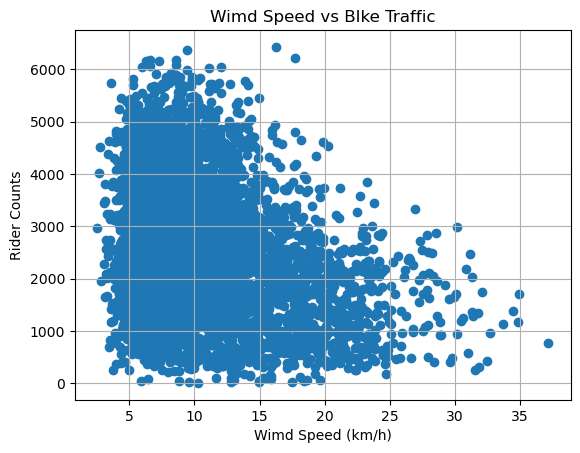

<Figure size 640x480 with 0 Axes>

In [38]:
plt.scatter(
    features_df["wind_speed_10m"],
    features_df["fremont_bridge"]
)
plt.grid()
plt.xlabel("Wimd Speed (km/h)")
plt.ylabel("Rider Counts")
plt.title("Wimd Speed vs BIke Traffic")
plt.show()

plt.savefig(
    "../reports/figures/wind_speed_vs_traffic.png",
    bbox_inches="tight"
)

In [39]:
#Weather Correlation table
weather_corr = features_df[
    [
        "fremont_bridge",
        "temperature_2m",
        "precipitation",
        "wind_speed_10m",
        "rolling_mean_7"
    ]
].corr()

weather_corr

,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,rolling_mean_7
fremont_bridge,1.000000,0.579876,-0.377144,-0.307724,0.727351
temperature_2m,0.579876,1.000000,-0.174119,-0.113918,0.780824
precipitation,-0.377144,-0.174119,1.000000,0.508591,-0.310919
wind_speed_10m,-0.307724,-0.113918,0.508591,1.000000,-0.267796
rolling_mean_7,0.727351,0.780824,-0.310919,-0.267796,1.000000


#### Interpretation

Lag features exhibit the strongest correlation with
daily ridership, indicating substantial autocorrelation
in the time series.

Weather variables remain informative predictors,
particularly temperature, though temporal features
appear to explain more variance.


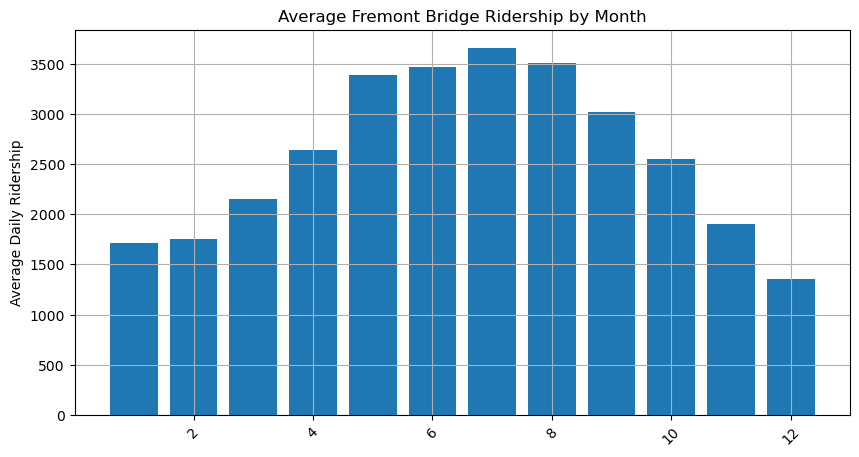

In [40]:
#Investingating seasonal effects
features_df.groupby(
    "month"
)[
    [
        "fremont_bridge",
        "temperature_2m",
        "precipitation"
    ]
].mean()

plt.figure(figsize=(10,5))

plt.bar(
    monthly_avg.index,
    monthly_avg.values
)

plt.xticks(rotation=45)
plt.ylabel("Average Daily Ridership")
plt.title("Average Fremont Bridge Ridership by Month")
plt.grid()
plt.show()

#### Interpretation

- Temperature shows a moderate positive relationship with bike traffic.
- Precipitation shows a negative relationship with bike traffic.
- Wind speed exhibits a weaker relationship.
- Weather appears to explain part of the seasonal variation in ridership, though lag and calendar effects are likely stronger predictors.

### Predictive Strength Analysis

This section examines the relationships between
engineered features and bicycle traffic to identify
which variables appear most useful for forecasting.

In [42]:
#investigate predictive strength of lag
corr_df = features_df[
    [
        "fremont_bridge",
        "temperature_2m",
        "precipitation",
        "wind_speed_10m",
        "lag_1",
        "lag_7",
        "rolling_mean_7"
    ]
].corr()

corr_df

,fremont_bridge,temperature_2m,precipitation,wind_speed_10m,lag_1,lag_7,rolling_mean_7
fremont_bridge,1.000000,0.579876,-0.377144,-0.307724,0.708754,0.769558,0.727351
temperature_2m,0.579876,1.000000,-0.174119,-0.113918,0.601452,0.558795,0.780824
precipitation,-0.377144,-0.174119,1.000000,0.508591,-0.296509,-0.188925,-0.310919
wind_speed_10m,-0.307724,-0.113918,0.508591,1.000000,-0.258159,-0.179707,-0.267796
lag_1,0.708754,0.601452,-0.296509,-0.258159,1.000000,0.614393,0.745490
lag_7,0.769558,0.558795,-0.188925,-0.179707,0.614393,1.000000,0.683229
rolling_mean_7,0.727351,0.780824,-0.310919,-0.267796,0.745490,0.683229,1.000000


#### Interpretation

Lagged traffic features exhibit the strongest
relationships with daily ridership. Traffic from
one week prior (lag_7) shows the highest correlation
with current traffic (r = 0.77), followed by the
seven-day rolling average (r = 0.73) and traffic from
the previous day (r = 0.71).

These results indicate substantial autocorrelation in
the time series and suggest that historical ridership
patterns are among the most important predictors for
forecasting.

Weather variables remain informative, particularly
temperature (r = 0.58), though temporal features
appear to explain more variation in ridership than
weather alone.